In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from diffusers import AutoPipelineForInpainting, EulerDiscreteScheduler
from diffusers.utils import load_image, make_image_grid
from simple_lama_inpainting import SimpleLama
from optimum.intel import OVStableDiffusionXLInpaintPipeline

Multiple distributions found for package optimum. Picked distribution: optimum
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [2]:
init_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png")
mask_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png")

# init_image = init_image.resize((200, 200))
# mask_image = mask_image.resize((200, 200))

prompt = "a black cat with glowing eyes, cute, adorable, disney, pixar, highly detailed, 8k"
negative_prompt = "bad anatomy, deformed, ugly, disfigured"

Text(0.5, 1.0, 'final result')

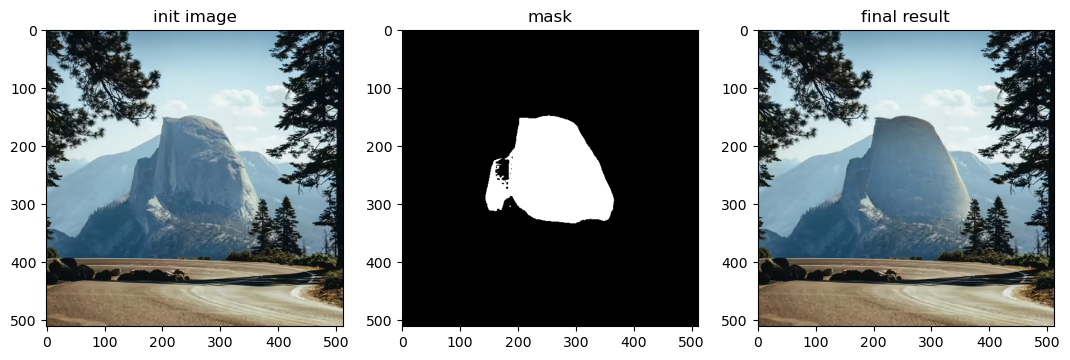

In [3]:
# LaMa: mask cleaning and object removal

# downloaded at C:\Users\zeyad\.cache\torch\hub\checkpoints
lama = SimpleLama()
result = lama(init_image, mask_image.convert("L"))


plt.figure(figsize=(13, 13))
plt.subplot(131)
plt.imshow(np.array(init_image))
plt.title("init image")

plt.subplot(132)
plt.imshow(np.array(mask_image))
plt.title("mask")

plt.subplot(133)
plt.imshow(np.array(result))
plt.title("final result")

In [ ]:
# SDXL-Lightning + OpenVINO (Highest Quality)

# Load the Intel-optimized version (first run downloads the converted model)
model_id = "stabilityai/sdxl-turbo"

pipe = OVStableDiffusionXLInpaintPipeline.from_pretrained(
    model_id,
    export=True,
    device="CPU"
)

pipe.reshape(batch_size=1, height=512, width=512, num_images_per_prompt=1)
pipe.compile()

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=4,  
    guidance_scale=0.0
).images[0]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\zeyad\.cache\huggingface\hub\models--stabilityai--sdxl-turbo. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/2.78G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

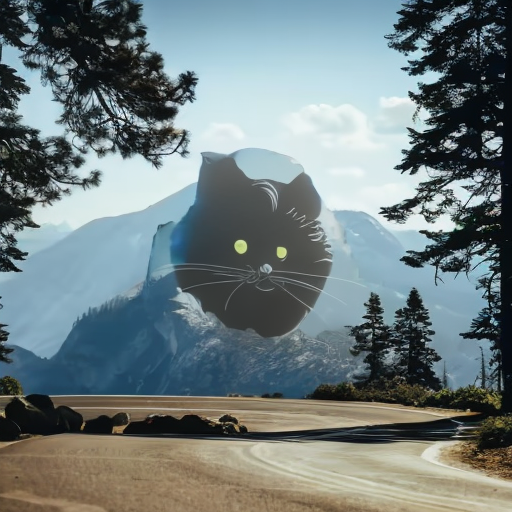

In [ ]:
image